<a href="https://colab.research.google.com/github/vakitideekshareddy-star/CSPT_ACE/blob/main/CSPT_day_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import math

def sigmoid(z):
    """Clips z to prevent math.exp overflow, then returns sigmoid."""
    z = max(-500, min(500, z))
    return 1.0 / (1.0 + math.exp(-z))

def dot_product(x, w):
    """Calculates the dot product of two vectors."""
    return sum(xi * wi for xi, wi in zip(x, w))

def compute_log_likelihood(X, y, weights, bias):
    """
    Calculates the Log-Likelihood of the dataset given the current parameters.
    Formula: Sum [ y*log(p) + (1-y)*log(1-p) ]
    """
    log_likelihood = 0.0
    epsilon = 1e-15 # To prevent log(0)

    for i in range(len(X)):
        linear_combination = dot_product(X[i], weights) + bias
        p = sigmoid(linear_combination)

        # Clip probability to avoid math domain error (log of 0)
        p = max(epsilon, min(1 - epsilon, p))

        if y[i] == 1:
            log_likelihood += math.log(p)
        else:
            log_likelihood += math.log(1 - p)

    return log_likelihood

def optimize_parameters(X, y, learning_rate=0.1, epochs=1000):
    """
    Maximizes the Log-Likelihood using Gradient Ascent.
    """
    n_samples = len(X)
    n_features = len(X[0])

    # Initialize parameters
    weights = [0.0] * n_features
    bias = 0.0

    # Track likelihood for monitoring
    history = []

    for epoch in range(epochs):
        dw = [0.0] * n_features
        db = 0.0

        # Calculate gradients for the whole dataset
        for i in range(n_samples):
            linear_combination = dot_product(X[i], weights) + bias
            p = sigmoid(linear_combination)

            # The gradient of Log-Likelihood with respect to z is (y - p)
            gradient_z = y[i] - p

            # Accumulate gradients for weights and bias
            for j in range(n_features):
                dw[j] += gradient_z * X[i][j]
            db += gradient_z

        # Gradient Ascent: Update parameters to MAXIMIZE log-likelihood
        # We divide by n_samples to take the average gradient step
        for j in range(n_features):
            weights[j] += learning_rate * (dw[j] / n_samples)
        bias += learning_rate * (db / n_samples)

        # Record Log-Likelihood every 100 epochs
        if epoch % 100 == 0 or epoch == epochs - 1:
            ll = compute_log_likelihood(X, y, weights, bias)
            history.append((epoch, ll))

    return weights, bias, history

def predict(X, weights, bias, threshold=0.5):
    """Predicts class labels (0 or 1)."""
    predictions = []
    for x in X:
        p = sigmoid(dot_product(x, weights) + bias)
        predictions.append(1 if p >= threshold else 0)
    return predictions

Final Weights: [2.299199362989657, -0.059316578262334795]
Final Bias: -9.764375890480661
Final Log-Likelihood: -0.0874


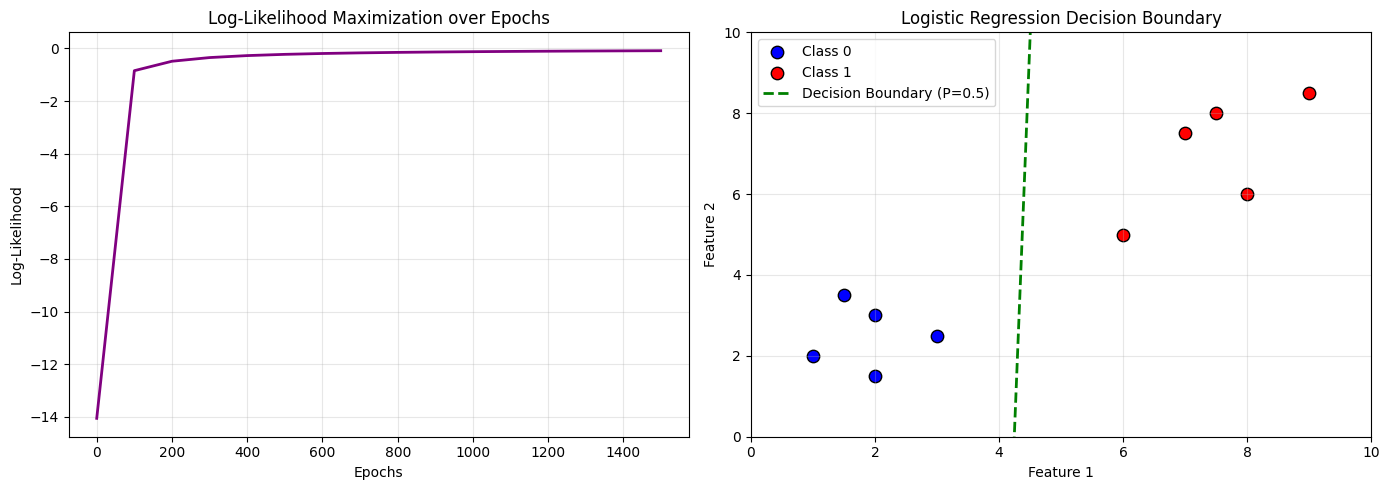

In [3]:
import matplotlib.pyplot as plt

# 1. Create a 2D dummy dataset using standard Python lists
X = [
    [1.0, 2.0], [2.0, 1.5], [2.0, 3.0], [3.0, 2.5], [1.5, 3.5], # Class 0
    [6.0, 5.0], [7.0, 7.5], [8.0, 6.0], [9.0, 8.5], [7.5, 8.0]  # Class 1
]
y = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

# 2. Optimize parameters (Train the model)
learning_rate = 0.5
epochs = 1500
weights, bias, ll_history = optimize_parameters(X, y, learning_rate, epochs)

print(f"Final Weights: {weights}")
print(f"Final Bias: {bias}")
print(f"Final Log-Likelihood: {ll_history[-1][1]:.4f}")

# 3. Plotting Setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot A: Log-Likelihood Optimization Curve ---
epochs_plot = [item[0] for item in ll_history]
ll_plot = [item[1] for item in ll_history]

ax1.plot(epochs_plot, ll_plot, color='purple', linewidth=2)
ax1.set_title('Log-Likelihood Maximization over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Log-Likelihood')
ax1.grid(True, alpha=0.3)

# --- Plot B: Decision Boundary ---
# Separate classes for scatter plot
x1_c0 = [X[i][0] for i in range(len(X)) if y[i] == 0]
x2_c0 = [X[i][1] for i in range(len(X)) if y[i] == 0]
x1_c1 = [X[i][0] for i in range(len(X)) if y[i] == 1]
x2_c1 = [X[i][1] for i in range(len(X)) if y[i] == 1]

ax2.scatter(x1_c0, x2_c0, color='blue', label='Class 0', s=80, edgecolors='k')
ax2.scatter(x1_c1, x2_c1, color='red', label='Class 1', s=80, edgecolors='k')

# Calculate the Decision Boundary: w1*x1 + w2*x2 + bias = 0  --> x2 = -(w1*x1 + bias) / w2
x_boundary = [0, 10]
y_boundary = [-(weights[0] * x + bias) / weights[1] for x in x_boundary]

ax2.plot(x_boundary, y_boundary, color='green', linestyle='--', linewidth=2, label='Decision Boundary (P=0.5)')

ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title('Logistic Regression Decision Boundary')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()